# Missing-Object-Oriented Target-Val Analysis

This notebook revisits the missed-object analysis with a cleaner proxy design.

The previous version mainly used **counts** of latent low-confidence queries. That turned out to be too coarse. In this revision, we use **continuous query-level scores** and then aggregate them into image-level proxies in two ways:

- average over all latent candidates
- top-k average over the strongest latent candidates

We also compare several simple image-level combinations after percentile-rank normalization.

The goal stays the same: understand whether DINO exposes any useful **source-free signal for hidden / undetected objects** on `target_val`.


In [1]:
from __future__ import annotations

from pathlib import Path
import os
import random
import sys

NOTEBOOK_GPU = 0
if NOTEBOOK_GPU is not None:
    os.environ["CUDA_VISIBLE_DEVICES"] = str(NOTEBOOK_GPU)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from matplotlib.patches import Rectangle
from IPython.display import display
from detectron2.checkpoint import DetectionCheckpointer

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.config import load_config
from src.data.daod import (
    build_daod_dataset,
    classify_detection_errors,
    make_strong_view,
    make_weak_view,
    map_boxes_to_original_view,
    percentile_rank_normalize,
    raw_output_to_query_rows,
    score_cross_view_support,
    score_geometry_structure,
    score_semantic_structure,
    summarize_scores,
)
from src.engine.utils import resolve_daod_source_run_dir
from src.models.detrex_adapter import build_daod_model, run_daod_inference_with_raw


/local/home/ljzhang/code/SFADA/external/detrex/detrex/layers/dcn_v3.py:23: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/local/home/ljzhang/code/SFADA/external/detrex/detrex/layers/dcn_v3.py:52: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/ljzhang/conda/envs/sfada/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ljzhang/conda/envs/sfada/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers",

## 1. Setup

We restore the source-trained detector and prepare the `target_val` split.

GT is used only to define the analysis target:

- missed-object count
- missed-object rate

All candidate proxies themselves use only model behavior.


In [2]:
CONFIG_PATH = REPO_ROOT / "configs/daod/source_cityscapes_to_foggy_cityscapes_dino.yaml"
cfg = load_config(CONFIG_PATH)

run_dir = REPO_ROOT / resolve_daod_source_run_dir(cfg)
checkpoint_path = run_dir / "model_best.pth"
if not checkpoint_path.exists():
    checkpoint_path = run_dir / "model_final.pth"
assert checkpoint_path.exists(), checkpoint_path

adapter = build_daod_model(cfg, load_weights=False)
load_report = DetectionCheckpointer(adapter.model).load(str(checkpoint_path))
adapter.model.eval()

target_val_dataset = build_daod_dataset(cfg, split="target_val", transform=None)

print("CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("checkpoint =", checkpoint_path)
print("target_val size =", len(target_val_dataset))
print("load report keys =", sorted(load_report.keys()))


CUDA_VISIBLE_DEVICES = 0
checkpoint = /local/home/ljzhang/code/SFADA/runs/daod_source/cityscapes__to__foggy_cityscapes/dino_r50_4scale_12ep/model_final.pth
target_val size = 500
load report keys = ['trainer']


## 2. Working definitions

### GT undetectability targets

We keep two GT targets:

- **missed-object count**: how many GT objects have no nearby prediction at all
- **missed-object rate**: missed-object count divided by GT object count

The rate is the main target because it is less dominated by image crowdedness.

### Query-level proxy families

For each low-confidence original-view query, we compute three continuous scores in `[0, 1]`:

- **semantic structure**: low foreground entropy and high top-class margin
- **geometry structure**: stable decoder-layer box refinement
- **cross-view support**: similar low-confidence evidence appears again in weak or strong view

### Image-level aggregation

For each proxy family we compare two image-level summaries:

- **mean over all latent queries**
- **top-k mean** over the strongest latent queries

This lets us test whether the useful signal is diffuse or concentrated in only a few strong candidates.


In [3]:
PREDICTION_SCORE_THRESHOLD = 0.30
GT_MATCH_IOU_THRESHOLD = 0.50
NEARBY_IOU_THRESHOLD = 0.10
LATENT_SCORE_FLOOR = 0.05
TOP_K = 5
CROSS_VIEW_IOU_THRESH = 0.30
RNG = random.Random(0)


## 3. Small notebook helpers

These helpers keep the main loop readable.


In [4]:
def clone_with_in_memory_image(sample: dict, image: Image.Image, view_name: str) -> dict:
    """Reuse one dataset sample but override the in-memory image payload."""

    cloned_sample = dict(sample)
    cloned_sample["image"] = image
    cloned_sample["sample_id"] = f"{sample['sample_id']}::{view_name}"
    return cloned_sample


def remap_query_rows_to_original_coordinates(query_rows: list[dict], view_metadata: dict) -> list[dict]:
    """Map transformed-view boxes back into original-image coordinates."""

    remapped_boxes = map_boxes_to_original_view([row["bbox"] for row in query_rows], view_metadata)
    remapped_rows = []
    for row, remapped_box in zip(query_rows, remapped_boxes):
        updated = dict(row)
        updated["bbox"] = remapped_box
        remapped_rows.append(updated)
    return remapped_rows


def spearman_rank_corr(x: pd.Series, y: pd.Series) -> float:
    """Return Spearman rank correlation with a NaN-safe fallback."""

    if x.nunique(dropna=True) <= 1 or y.nunique(dropna=True) <= 1:
        return float("nan")
    return float(x.corr(y, method="spearman"))


def draw_image_with_boxes(image_path: str, gt_boxes: list[list[float]], pred_boxes: list[list[float]], title: str) -> None:
    """Visualize GT boxes and selected latent query boxes on one image."""

    image = Image.open(image_path).convert("RGB")
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.imshow(image)
    for x0, y0, x1, y1 in gt_boxes:
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="lime", linewidth=2.0))
    for x0, y0, x1, y1 in pred_boxes:
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="red", linewidth=1.4))
    ax.set_title(title)
    ax.axis("off")
    plt.show()


## 4. Main per-image analysis pass

For each target-val image we:

1. run original / weak / strong inference
2. convert raw DINO outputs into one row per decoder query
3. keep only the low-confidence original queries in the latent range
4. compute continuous semantic / geometry / cross-view scores for each latent query
5. aggregate them into image-level proxy summaries


In [5]:
per_image_rows = []
image_cache = {}

for image_index in range(len(target_val_dataset)):
    sample = target_val_dataset[image_index]
    original_image = Image.open(sample["file_name"]).convert("RGB")

    weak_image, weak_view_metadata = make_weak_view(original_image.copy(), rng=RNG)
    strong_image, strong_view_metadata = make_strong_view(original_image.copy())

    original_output = run_daod_inference_with_raw(adapter, sample)[0]
    weak_output = run_daod_inference_with_raw(adapter, clone_with_in_memory_image(sample, weak_image, "weak"))[0]
    strong_output = run_daod_inference_with_raw(adapter, clone_with_in_memory_image(sample, strong_image, "strong"))[0]

    original_query_rows = raw_output_to_query_rows(
        original_output["raw_output"],
        image_size=(sample["height"], sample["width"]),
    )
    weak_query_rows = remap_query_rows_to_original_coordinates(
        raw_output_to_query_rows(weak_output["raw_output"], image_size=(sample["height"], sample["width"])),
        weak_view_metadata,
    )
    strong_query_rows = remap_query_rows_to_original_coordinates(
        raw_output_to_query_rows(strong_output["raw_output"], image_size=(sample["height"], sample["width"])),
        strong_view_metadata,
    )

    confident_prediction_rows = [
        {"bbox": row["bbox"], "score": row["score"], "category_id": row["category_id"]}
        for row in original_query_rows
        if row["score"] >= PREDICTION_SCORE_THRESHOLD
    ]
    typed_errors = classify_detection_errors(
        sample["annotations"],
        confident_prediction_rows,
        match_iou_thresh=GT_MATCH_IOU_THRESHOLD,
        nearby_iou_thresh=NEARBY_IOU_THRESHOLD,
    )

    latent_query_rows = [
        row for row in original_query_rows
        if LATENT_SCORE_FLOOR <= row["score"] < PREDICTION_SCORE_THRESHOLD
    ]
    weak_latent_rows = [
        row for row in weak_query_rows
        if LATENT_SCORE_FLOOR <= row["score"] < PREDICTION_SCORE_THRESHOLD
    ]
    strong_latent_rows = [
        row for row in strong_query_rows
        if LATENT_SCORE_FLOOR <= row["score"] < PREDICTION_SCORE_THRESHOLD
    ]

    semantic_scores = []
    geometry_scores = []
    cross_view_scores = []
    combined_query_scores = []
    latent_boxes = []

    for row in latent_query_rows:
        semantic_score = score_semantic_structure(row)
        geometry_score = score_geometry_structure(row)
        weak_support = score_cross_view_support(row, weak_latent_rows, match_iou_thresh=CROSS_VIEW_IOU_THRESH)
        strong_support = score_cross_view_support(row, strong_latent_rows, match_iou_thresh=CROSS_VIEW_IOU_THRESH)
        cross_view_score = max(weak_support, strong_support)

        semantic_scores.append(semantic_score)
        geometry_scores.append(geometry_score)
        cross_view_scores.append(cross_view_score)
        combined_query_scores.append((semantic_score * geometry_score * cross_view_score) ** (1.0 / 3.0))
        latent_boxes.append(row["bbox"])

    semantic_summary = summarize_scores(semantic_scores, top_k=TOP_K)
    geometry_summary = summarize_scores(geometry_scores, top_k=TOP_K)
    cross_view_summary = summarize_scores(cross_view_scores, top_k=TOP_K)
    combined_query_summary = summarize_scores(combined_query_scores, top_k=TOP_K)

    gt_object_count = float(len(sample["annotations"]))
    missed_object_count = float(typed_errors["miss_count"])
    missed_object_rate = missed_object_count / max(gt_object_count, 1.0)

    per_image_rows.append(
        {
            "sample_id": sample["sample_id"],
            "file_name": sample["file_name"],
            "gt_object_count": gt_object_count,
            "missed_object_count": missed_object_count,
            "missed_object_rate": missed_object_rate,
            "latent_query_count": float(len(latent_query_rows)),
            "semantic_mean_all": semantic_summary["mean_all"],
            "semantic_topk_mean": semantic_summary["mean_topk"],
            "semantic_max": semantic_summary["max"],
            "geometry_mean_all": geometry_summary["mean_all"],
            "geometry_topk_mean": geometry_summary["mean_topk"],
            "geometry_max": geometry_summary["max"],
            "cross_view_mean_all": cross_view_summary["mean_all"],
            "cross_view_topk_mean": cross_view_summary["mean_topk"],
            "cross_view_max": cross_view_summary["max"],
            "combined_query_mean_all": combined_query_summary["mean_all"],
            "combined_query_topk_mean": combined_query_summary["mean_topk"],
            "combined_query_max": combined_query_summary["max"],
        }
    )

    image_cache[sample["sample_id"]] = {
        "file_name": sample["file_name"],
        "gt_boxes": [ann["bbox"] for ann in sample["annotations"]],
        "latent_boxes": latent_boxes,
        "latent_query_rows": latent_query_rows,
    }

analysis_df = pd.DataFrame(per_image_rows)
display(analysis_df.head())
print("analysis_df shape =", analysis_df.shape)


/home/ljzhang/conda/envs/sfada/lib/python3.12/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


,sample_id,file_name,gt_object_count,missed_object_count,missed_object_rate,latent_query_count,semantic_mean_all,semantic_topk_mean,semantic_max,geometry_mean_all,geometry_topk_mean,geometry_max,cross_view_mean_all,cross_view_topk_mean,cross_view_max,combined_query_mean_all,combined_query_topk_mean,combined_query_max
0,target_val:frankfurt:frankfurt_000000_000294:b...,/home/ljzhang/data/ins-seg/cityscapes/leftImg8...,7.0,5.0,0.714286,8.0,0.430537,0.526824,0.561501,0.945339,0.970923,0.988892,1.000000,1.000000,1.000000,0.733254,0.799356,0.814936
1,target_val:frankfurt:frankfurt_000000_000576:b...,/home/ljzhang/data/ins-seg/cityscapes/leftImg8...,21.0,8.0,0.380952,28.0,0.271976,0.539174,0.603261,0.934485,0.978790,0.989499,1.000000,1.000000,1.000000,0.597560,0.790500,0.823666
2,target_val:frankfurt:frankfurt_000000_001016:b...,/home/ljzhang/data/ins-seg/cityscapes/leftImg8...,9.0,0.0,0.000000,7.0,0.347401,0.447138,0.613678,0.959058,0.972693,0.985326,0.794326,0.880132,0.984247,0.591515,0.674039,0.779708
3,target_val:frankfurt:frankfurt_000000_001236:b...,/home/ljzhang/data/ins-seg/cityscapes/leftImg8...,32.0,26.0,0.812500,5.0,0.286867,0.286867,0.612144,0.961218,0.961218,0.972501,0.467991,0.467991,0.864026,0.336845,0.336845,0.680464
4,target_val:frankfurt:frankfurt_000000_001751:b...,/home/ljzhang/data/ins-seg/cityscapes/leftImg8...,25.0,16.0,0.640000,8.0,0.296984,0.431522,0.602438,0.950726,0.967430,0.977850,1.000000,1.000000,1.000000,0.612487,0.739829,0.833430


analysis_df shape = (500, 18)


## 5. GT missed-object target distribution

We first inspect the two GT targets to understand the range of image difficulty.


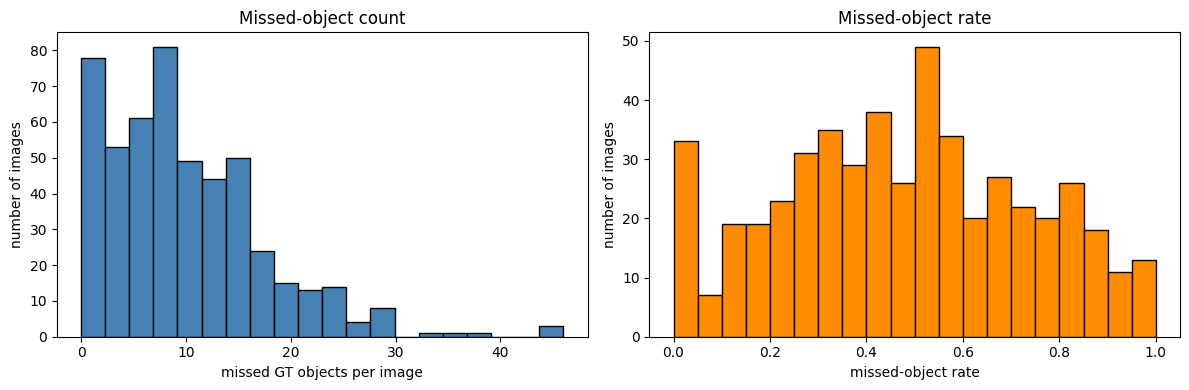

,count,mean,std,min,25%,50%,75%,max
gt_object_count,500.0,20.360000,11.380925,0.0,12.00000,19.000000,28.00000,66.0
missed_object_count,500.0,9.894000,7.543778,0.0,4.00000,9.000000,14.00000,46.0
missed_object_rate,500.0,0.474595,0.259469,0.0,0.28125,0.478636,0.68407,1.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(analysis_df["missed_object_count"], bins=20, color="steelblue", edgecolor="black")
axes[0].set_title("Missed-object count")
axes[0].set_xlabel("missed GT objects per image")
axes[0].set_ylabel("number of images")

axes[1].hist(analysis_df["missed_object_rate"], bins=20, color="darkorange", edgecolor="black")
axes[1].set_title("Missed-object rate")
axes[1].set_xlabel("missed-object rate")
axes[1].set_ylabel("number of images")
plt.tight_layout()
plt.show()

display(analysis_df[["gt_object_count", "missed_object_count", "missed_object_rate"]].describe().T)


## 6. Proxy distributions

We inspect the continuous image-level proxy summaries before correlation analysis.

The columns ending in:

- `mean_all`: average over all latent low-confidence queries in the image
- `topk_mean`: average over the strongest `TOP_K` latent queries
- `max`: strongest single latent query in the image


In [7]:
proxy_columns = [
    "semantic_mean_all", "semantic_topk_mean", "semantic_max",
    "geometry_mean_all", "geometry_topk_mean", "geometry_max",
    "cross_view_mean_all", "cross_view_topk_mean", "cross_view_max",
    "combined_query_mean_all", "combined_query_topk_mean", "combined_query_max",
]

display(analysis_df[proxy_columns].describe().T)


,count,mean,std,min,25%,50%,75%,max
semantic_mean_all,500.0,0.264765,0.095734,0.0,0.213217,0.269277,0.319488,0.678879
semantic_topk_mean,500.0,0.411397,0.157060,0.0,0.328645,0.429781,0.518720,0.780345
semantic_max,500.0,0.530954,0.172938,0.0,0.463170,0.568301,0.645199,0.843364
geometry_mean_all,500.0,0.925498,0.152285,0.0,0.937188,0.950240,0.962671,0.991175
geometry_topk_mean,500.0,0.949520,0.155722,0.0,0.968920,0.977276,0.983042,0.991175
geometry_max,500.0,0.959075,0.157094,0.0,0.982277,0.986668,0.989687,0.995544
cross_view_mean_all,500.0,0.808082,0.244860,0.0,0.645737,1.000000,1.000000,1.000000
cross_view_topk_mean,500.0,0.898015,0.204381,0.0,0.897120,1.000000,1.000000,1.000000
cross_view_max,500.0,0.943268,0.172157,0.0,0.957106,1.000000,1.000000,1.000000
combined_query_mean_all,500.0,0.520191,0.148544,0.0,0.453134,0.546594,0.618471,0.806282


## 7. Correlation analysis: which continuous proxy works best?

We compare each proxy summary against both GT targets.

The main question is whether moving from count-based summaries to continuous scores gives a stronger ranking relationship with missed-object difficulty.


In [8]:
correlation_rows = []
for proxy_column in proxy_columns:
    correlation_rows.append(
        {
            "proxy": proxy_column,
            "SROCC with missed-object count": spearman_rank_corr(analysis_df[proxy_column], analysis_df["missed_object_count"]),
            "SROCC with missed-object rate": spearman_rank_corr(analysis_df[proxy_column], analysis_df["missed_object_rate"]),
        }
    )
correlation_df = pd.DataFrame(correlation_rows).sort_values(by="SROCC with missed-object rate", ascending=False)
display(correlation_df)


,proxy,SROCC with missed-object count,SROCC with missed-object rate
3,geometry_mean_all,0.025591,0.340847
0,semantic_mean_all,0.083981,-0.016049
9,combined_query_mean_all,0.032361,-0.030179
6,cross_view_mean_all,0.003181,-0.030783
8,cross_view_max,0.016786,-0.081116
7,cross_view_topk_mean,0.043242,-0.086187
5,geometry_max,0.056213,-0.145435
4,geometry_topk_mean,0.110149,-0.208224
11,combined_query_max,0.133075,-0.222016
2,semantic_max,0.151094,-0.232676


## 8. Full average versus top-k average

This block directly tests the design choice we discussed.

- `mean_all` asks whether latent evidence is spread across many queries
- `topk_mean` asks whether only a few strongest latent candidates matter


In [9]:
aggregation_comparison_rows = []
for family in ["semantic", "geometry", "cross_view", "combined_query"]:
    aggregation_comparison_rows.append(
        {
            "family": family,
            "mean_all SROCC": spearman_rank_corr(analysis_df[f"{family}_mean_all"], analysis_df["missed_object_rate"]),
            "topk_mean SROCC": spearman_rank_corr(analysis_df[f"{family}_topk_mean"], analysis_df["missed_object_rate"]),
            "max SROCC": spearman_rank_corr(analysis_df[f"{family}_max"], analysis_df["missed_object_rate"]),
        }
    )
aggregation_df = pd.DataFrame(aggregation_comparison_rows)
display(aggregation_df)


,family,mean_all SROCC,topk_mean SROCC,max SROCC
0,semantic,-0.016049,-0.325319,-0.232676
1,geometry,0.340847,-0.208224,-0.145435
2,cross_view,-0.030783,-0.086187,-0.081116
3,combined_query,-0.030179,-0.311310,-0.222016


## 9. Normalized proxy combinations

Now we combine one image-level score per family.

We normalize each chosen image-level proxy by percentile rank into `[0, 1]`, then try:

- arithmetic mean
- geometric mean
- product

We use the `topk_mean` version for each family as the default image-level input to combination, because it is the most focused summary of the strongest latent candidates.


In [10]:
analysis_df["semantic_norm"] = percentile_rank_normalize(analysis_df["semantic_topk_mean"])
analysis_df["geometry_norm"] = percentile_rank_normalize(analysis_df["geometry_topk_mean"])
analysis_df["cross_view_norm"] = percentile_rank_normalize(analysis_df["cross_view_topk_mean"])

proxy_matrix = analysis_df[["semantic_norm", "geometry_norm", "cross_view_norm"]].to_numpy(dtype=float)
analysis_df["combo_arithmetic_mean"] = proxy_matrix.mean(axis=1)
analysis_df["combo_geometric_mean"] = np.prod(np.clip(proxy_matrix, 1e-8, 1.0), axis=1) ** (1.0 / proxy_matrix.shape[1])
analysis_df["combo_product"] = np.prod(np.clip(proxy_matrix, 0.0, 1.0), axis=1)

combo_columns = ["combo_arithmetic_mean", "combo_geometric_mean", "combo_product"]
combo_rows = []
for combo_column in combo_columns:
    combo_rows.append(
        {
            "proxy combination": combo_column,
            "SROCC with missed-object count": spearman_rank_corr(analysis_df[combo_column], analysis_df["missed_object_count"]),
            "SROCC with missed-object rate": spearman_rank_corr(analysis_df[combo_column], analysis_df["missed_object_rate"]),
        }
    )
combo_df = pd.DataFrame(combo_rows).sort_values(by="SROCC with missed-object rate", ascending=False)
display(combo_df)


,proxy combination,SROCC with missed-object count,SROCC with missed-object rate
0,combo_arithmetic_mean,0.121246,-0.307823
1,combo_geometric_mean,0.135701,-0.312096
2,combo_product,0.135701,-0.312096


## 10. Scatter plots for the strongest relationships

We visualize the best single continuous proxy and the best normalized combination against missed-object rate.


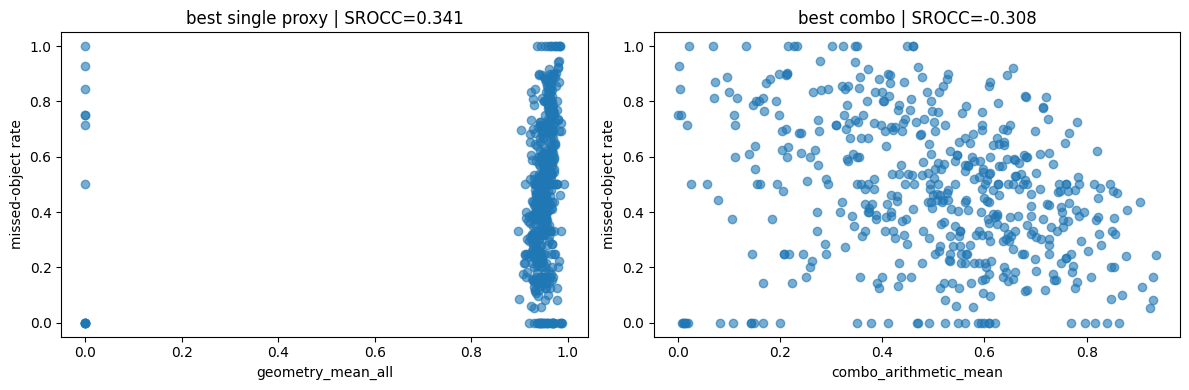

In [11]:
best_single_proxy = correlation_df.iloc[0]["proxy"]
best_combo_proxy = combo_df.iloc[0]["proxy combination"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(analysis_df[best_single_proxy], analysis_df["missed_object_rate"], alpha=0.6)
axes[0].set_xlabel(best_single_proxy)
axes[0].set_ylabel("missed-object rate")
axes[0].set_title(f"best single proxy | SROCC={spearman_rank_corr(analysis_df[best_single_proxy], analysis_df['missed_object_rate']):.3f}")

axes[1].scatter(analysis_df[best_combo_proxy], analysis_df["missed_object_rate"], alpha=0.6)
axes[1].set_xlabel(best_combo_proxy)
axes[1].set_ylabel("missed-object rate")
axes[1].set_title(f"best combo | SROCC={spearman_rank_corr(analysis_df[best_combo_proxy], analysis_df['missed_object_rate']):.3f}")
plt.tight_layout()
plt.show()


## 11. Qualitative inspection of hard images

We inspect a few of the hardest images by missed-object rate and overlay the latent low-confidence query boxes. This helps us judge whether the continuous proxies are highlighting plausible hidden objects or just clutter.


,sample_id,missed_object_count,missed_object_rate,semantic_topk_mean,geometry_topk_mean,cross_view_topk_mean,combo_geometric_mean
23,target_val:frankfurt:frankfurt_000000_011007:b...,7.0,1.0,0.204415,0.945256,1.000000,0.144403
111,target_val:frankfurt:frankfurt_000001_023235:b...,6.0,1.0,0.316197,0.960720,1.000000,0.256911
328,target_val:munster:munster_000002_000019:beta=...,14.0,1.0,0.279462,0.966205,0.370284,0.109133


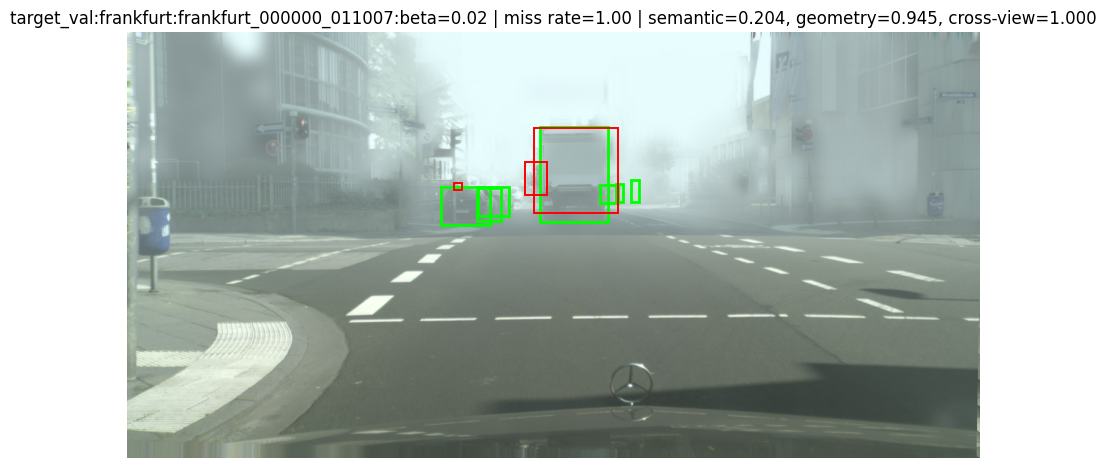

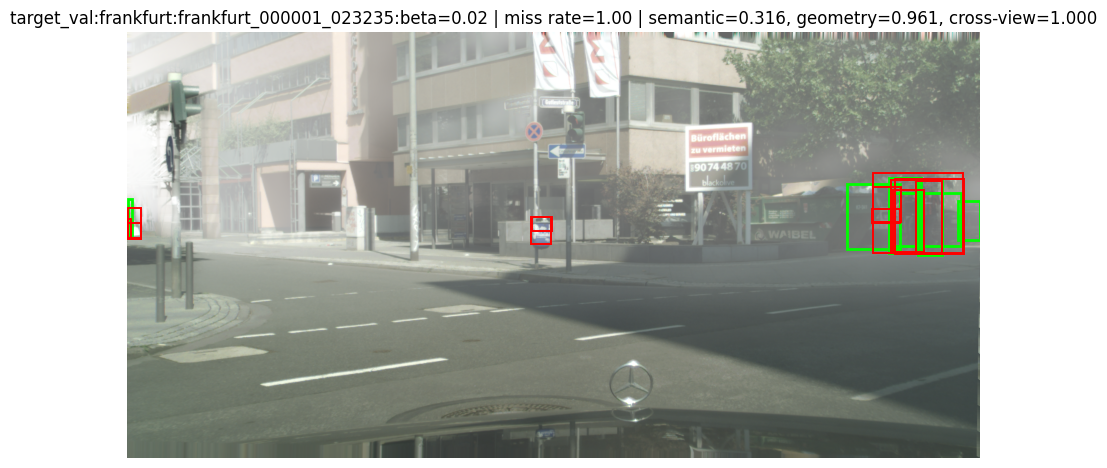

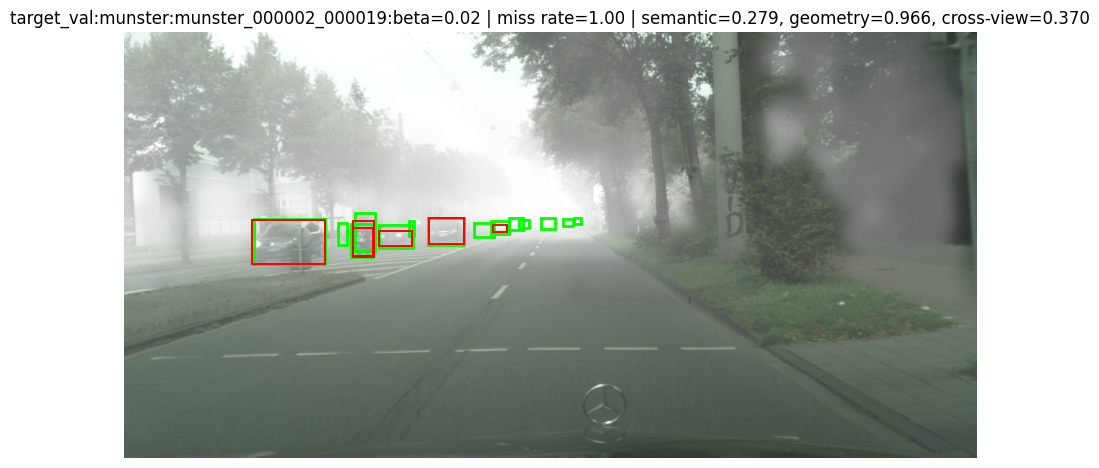

In [12]:
hardest_rows = analysis_df.sort_values(by="missed_object_rate", ascending=False).head(3)
display(
    hardest_rows[[
        "sample_id", "missed_object_count", "missed_object_rate",
        "semantic_topk_mean", "geometry_topk_mean", "cross_view_topk_mean",
        "combo_geometric_mean",
    ]]
)

for _, row in hardest_rows.iterrows():
    payload = image_cache[row["sample_id"]]
    draw_image_with_boxes(
        payload["file_name"],
        payload["gt_boxes"],
        payload["latent_boxes"][:25],
        title=(
            f"{row['sample_id']} | miss rate={row['missed_object_rate']:.2f} | "
            f"semantic={row['semantic_topk_mean']:.3f}, geometry={row['geometry_topk_mean']:.3f}, "
            f"cross-view={row['cross_view_topk_mean']:.3f}"
        ),
    )


## 12. Summary

This closing cell keeps the result readable as a short analysis note.


In [13]:
summary_table = pd.DataFrame(
    [
        {"item": "GT targets", "result": "missed-object count and missed-object rate"},
        {"item": "best single continuous proxy", "result": f"{best_single_proxy} (SROCC={spearman_rank_corr(analysis_df[best_single_proxy], analysis_df['missed_object_rate']):.3f})"},
        {"item": "best normalized combination", "result": f"{best_combo_proxy} (SROCC={spearman_rank_corr(analysis_df[best_combo_proxy], analysis_df['missed_object_rate']):.3f})"},
        {"item": "aggregation check", "result": "compare full average, top-k average, and max for each proxy family"},
    ]
)
display(summary_table)
print(
    "Interpretation: if top-k summaries beat full averages, the useful latent evidence is concentrated in a few strong candidates. "
    "If full averages work better, the signal is more diffuse across many low-confidence queries."
)


,item,result
0,GT targets,missed-object count and missed-object rate
1,best single continuous proxy,geometry_mean_all (SROCC=0.341)
2,best normalized combination,combo_arithmetic_mean (SROCC=-0.308)
3,aggregation check,"compare full average, top-k average, and max f..."


Interpretation: if top-k summaries beat full averages, the useful latent evidence is concentrated in a few strong candidates. If full averages work better, the signal is more diffuse across many low-confidence queries.
